In [1]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import SequentialFeatureSelector, RFECV, SelectFromModel

import folium
from sklearn.decomposition import PCA

from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor

from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.metrics import r2_score

from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.inspection import PartialDependenceDisplay

from sklearn.feature_selection import RFE


1. WCZYTANIE, PODZIAŁ DANYCH NA ZBIÓR TRENINGOWY/TESTOWY I PRZYGOTOWANIE PIPELINE'U

In [2]:
key = 'sample_apartments_lyon'
data = pd.read_csv(f'D:\\nieruchomosci_ostateczne\\samples\\sample_final\\{key}.txt', low_memory=False)
#data = data[data.year == 2019]

In [27]:
num_features_1 = ['longitude', 'latitude', 'full_built_surface', 'number_of_rooms', 'year', 'quarter', 'postal_code']

num_features_2 = ['population_density']

num_features_3 = ['n_factors_shop_100', 'n_factors_shop_500', 'n_factors_shop_1000', 'n_factors_amenity_100', 'n_factors_amenity_500', 'n_factors_amenity_1000',
       'n_factors_healthcare_100', 'n_factors_healthcare_500', 'n_factors_healthcare_1000', 'n_factors_natural_100', 'n_factors_natural_500', 'n_factors_natural_1000', 
       'n_factors_public_transport_100', 'n_factors_public_transport_500', 'n_factors_public_transport_1000', 'n_factors_all_100', 'n_factors_all_500', 'n_factors_all_1000']

num_features_4 = ['closest_hospital_EXACT_dist_m', 'closest_school_EXACT_dist_m', 'closest_transport_EXACT_dist_m', 'closest_shop_EXACT_dist_m', 'closest_natural_EXACT_dist_m', 
                  'closest_transport_subway_EXACT_dist_m', 'closest_culture_EXACT_dist_m', 'closest_sport_EXACT_dist_m'] 
       
num_features_5 = ['dist_to_big_city_km']

num_features_6 = ['avg_building_age', 'avg_building_floor', 'dpe_good', 'dpe_medium', 'dpe_bad']


num_features = num_features_1 + num_features_2 + num_features_3 + num_features_4 + num_features_5 + num_features_6
#num_features = ['full_built_surface', 'year', 'postal_code', 'n_factors_all_500', 'number_of_rooms', 'latitude']

cat_features = []
targ = ['property_value']


In [28]:
# losowy podział danych #

Xy = data.loc[:, data.columns.isin(num_features + cat_features + targ)]
X = Xy.drop(columns = targ[0])
y = Xy[targ[0]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=4747)

tworzenie pipeline'u

In [29]:
def make_pipeline(num_features, cat_features, imputer = False, scaler=False, variance=False, selector=None, model=None):
    
    num_steps, cat_steps = [], []

    if imputer:
        num_steps.append(("imputer", SimpleImputer(strategy="mean")))
        cat_steps.append(("imputer", SimpleImputer(strategy="most_frequent")))
    
    if scaler:
        num_steps.append(("scaler", StandardScaler()))
    
    num_pipeline = Pipeline(num_steps)

    cat_steps.append(("encoder", OneHotEncoder(handle_unknown="ignore")))
    cat_pipeline = Pipeline(cat_steps)

    preprocessor = ColumnTransformer([("num", num_pipeline, num_features), ("cat", cat_pipeline, cat_features)])

    steps = [("preprocessor", preprocessor)]

    if variance:
        steps.append(("variance", VarianceThreshold(threshold=0.01)))

    if selector is not None:
        steps.append(("features_selector", selector))
    
    if model is not None:
        steps.append(("model", model))

    return Pipeline(steps)

2. SELEKCJA ZMIENNYCH

In [30]:
model_name = "xgb"
selector_type = "importance"
k = 25

tune_selector = True
selector_cv = 3

In [31]:
def get_model(model_name):
    if model_name == "xgb":
        return XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)
    
    elif model_name == "lgbm":
        return LGBMRegressor(random_state=42,n_jobs=-1, verbose = -1)
    

def extract_selected_features(topk_features):
    final_features_num = []
    final_features_cat = []

    for f in topk_features:
        if f.startswith("num__"):
            final_features_num.append(f.replace("num__", ""))
        elif f.startswith("cat__"):
            col = f.replace("cat__", "").split("_")[0]
            final_features_cat.append(col)

    final_features_cat = list(dict.fromkeys(final_features_cat))
    return final_features_num, final_features_cat

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Najlepsze parametry dla importance:
{'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.1}


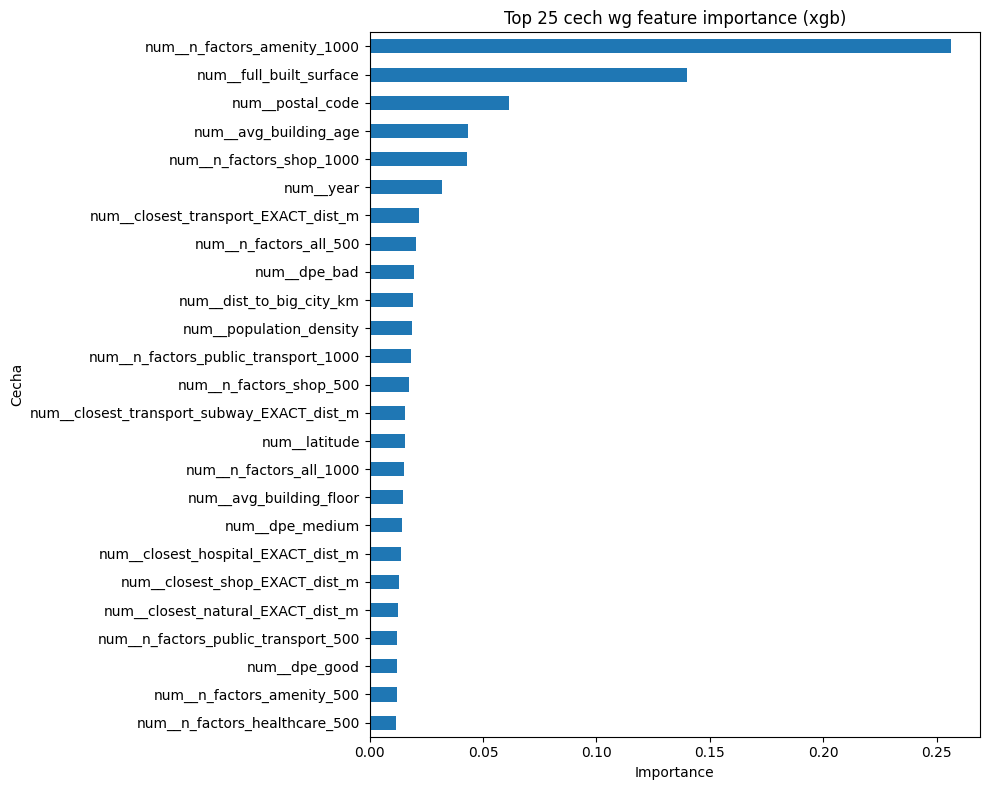

In [32]:
base_model = get_model(model_name)

if selector_type == "none":
    final_features_num = num_features
    final_features_cat = cat_features
    final_features = final_features_num + final_features_cat

    X_train_final = X_train[final_features]
    X_test_final = X_test[final_features]


elif selector_type == "importance":
    
    pipe_selector = make_pipeline(
        num_features=num_features,
        cat_features=cat_features,
        imputer=True,
        scaler=False,
        variance=False,
        selector=None,
        model=base_model
    )

    # tuning tylko dla importance
    if tune_selector:
        param_grid_importance = {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [3, 5, 7, 10],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1]
        }

        search_selector = RandomizedSearchCV(
            estimator=pipe_selector,
            param_distributions=param_grid_importance,
            n_iter=10,
            scoring="neg_root_mean_squared_error",
            cv=3,
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

        search_selector.fit(X_train, y_train)
        pipe_selector = search_selector.best_estimator_

        print("Najlepsze parametry dla importance:")
        print(search_selector.best_params_)

    else:
        pipe_selector.fit(X_train, y_train)

    feature_names = pipe_selector.named_steps["preprocessor"].get_feature_names_out()
    importances = pipe_selector.named_steps["model"].feature_importances_

    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    topk_features = feat_imp.head(k).index.tolist()
    topk_imp = feat_imp.head(k).sort_values(ascending=True)

    plt.figure(figsize=(10, 8))
    topk_imp.plot(kind="barh")
    plt.title(f"Top {k} cech wg feature importance ({model_name})")
    plt.xlabel("Importance")
    plt.ylabel("Cecha")
    plt.tight_layout()
    plt.show()

    final_features_num, final_features_cat = extract_selected_features(topk_features)
    final_features = final_features_num + final_features_cat

    X_train_final = X_train[final_features]
    X_test_final = X_test[final_features]


elif selector_type == "rfe":
    
    rfe_selector = RFE(estimator=base_model, n_features_to_select=k, step=1)

    pipe_selector = make_pipeline(
        num_features=num_features,
        cat_features=cat_features,
        imputer=True,
        scaler=False,
        variance=False,
        selector=rfe_selector,
        model=None
    )

    pipe_selector.fit(X_train, y_train)

    feature_names = pipe_selector.named_steps["preprocessor"].get_feature_names_out()
    selected_mask = pipe_selector.named_steps["features_selector"].get_support()
    topk_features = feature_names[selected_mask].tolist()

    print("Wybrane cechy przez RFE:")
    print(topk_features)

    final_features_num, final_features_cat = extract_selected_features(topk_features)
    final_features = final_features_num + final_features_cat

    X_train_final = X_train[final_features]
    X_test_final = X_test[final_features]

3. WŁAŚCIWE MODELE

In [33]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

models = {
    "xgb": make_pipeline(
        num_features=final_features_num,
        cat_features=final_features_cat,
        imputer=True,
        scaler=False,
        variance=False,
        selector=None,
        model=XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)
    ),
    
    "lgbm": make_pipeline(
        num_features=final_features_num,
        cat_features=final_features_cat,
        imputer=True,
        scaler=False,
        variance=False,
        selector=None,
        model=LGBMRegressor(random_state=42, n_jobs=-1)
    ),
    
    "rf": make_pipeline(
        num_features=final_features_num,
        cat_features=final_features_cat,
        imputer=True,
        scaler=False,
        variance=False,
        selector=None,
        model=RandomForestRegressor(random_state=42, n_jobs=-1)
    ),

    "knn": make_pipeline(
        num_features=final_features_num,
        cat_features=final_features_cat,
        imputer=True,
        scaler=True,   # <-- WAŻNE
        variance=False,
        selector=None,
        model=KNeighborsRegressor()
    ),

    "linear": make_pipeline(
        num_features=final_features_num,
        cat_features=final_features_cat,
        imputer=True,
        scaler=True,   # <-- WAŻNE
        variance=False,
        selector=None,
        model=LinearRegression()
    )
}

param_dists = {
    "xgb": {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.03, 0.05],
        "model__subsample": [0.7, 0.8, 0.9],
        "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9],
        "model__min_child_weight": [3, 5, 10, 15],
        "model__gamma": [0, 0.1, 0.3, 0.5],
        "model__reg_alpha": [0.1, 1, 5, 10],
        "model__reg_lambda": [5, 10, 20, 50]
    },

    "lgbm": {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__learning_rate": [0.01, 0.03, 0.05],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__num_leaves": [7, 15, 31, 50],
        "model__subsample": [0.7, 0.8, 0.9],
        "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9],
        "model__min_child_samples": [10, 20, 30, 50, 80],
        "model__min_split_gain": [0, 0.1, 0.3, 0.5],
        "model__reg_alpha": [0.1, 1, 5, 10],
        "model__reg_lambda": [1, 5, 10, 20, 50]
    },

    "rf": {
        "model__n_estimators": [300, 500, 800],
        "model__max_depth": [8, 12, 16, 20],
        "model__min_samples_split": [5, 10, 20, 30],
        "model__min_samples_leaf": [2, 5, 10, 20],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7]
    },

    "knn": {
        "model__n_neighbors": [50, 75, 100, 150, 200, 300],
        "model__weights": ["uniform"],
        "model__p": [1, 2]
    },

    "linear": {
    }
}


========== XGB ==========
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Najlepsze parametry:
{'model__subsample': 0.9, 'model__reg_lambda': 20, 'model__reg_alpha': 0.1, 'model__n_estimators': 1200, 'model__min_child_weight': 5, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.6}
CV RMSE: 53542.986399966656
RMSE TRAIN: 38447.76386405135
RMSE TEST: 52439.87727781704


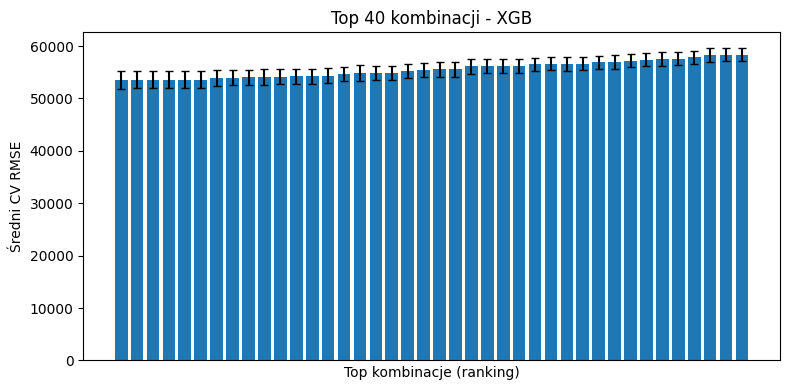


========== LGBM ==========
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3955
[LightGBM] [Info] Number of data points in the train set: 28774, number of used features: 25
[LightGBM] [Info] Start training from score 245347.119975
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

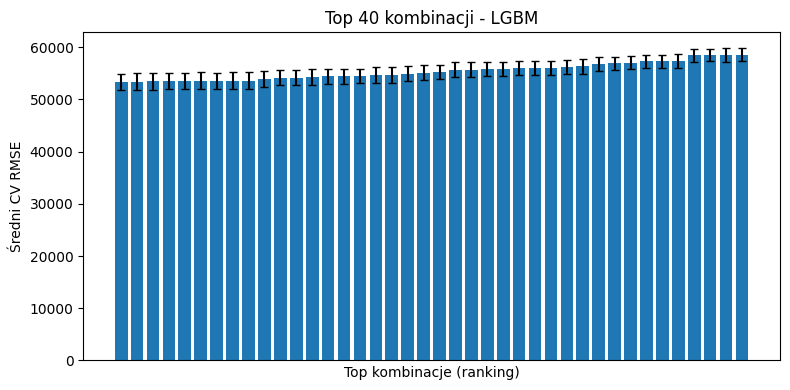


========== RF ==========
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Najlepsze parametry:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20}
CV RMSE: 55213.16732057198
RMSE TRAIN: 29648.434981838225
RMSE TEST: 55027.05870866432


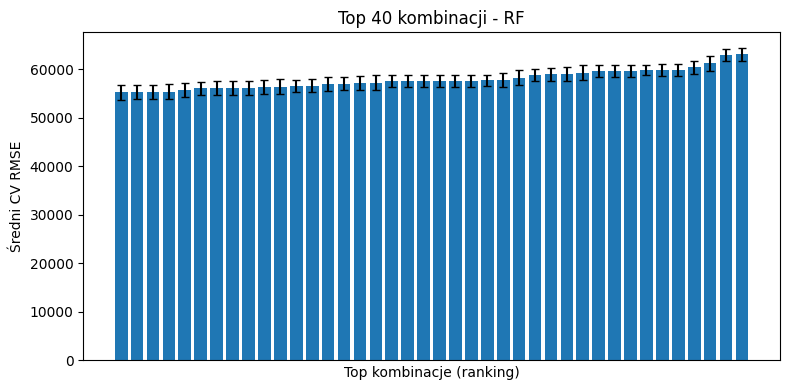


========== KNN ==========
Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\jpiec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:318: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Najlepsze parametry:
{'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 50}
CV RMSE: 72221.13655305697
RMSE TRAIN: 69341.46603672967
RMSE TEST: 70707.42525581343


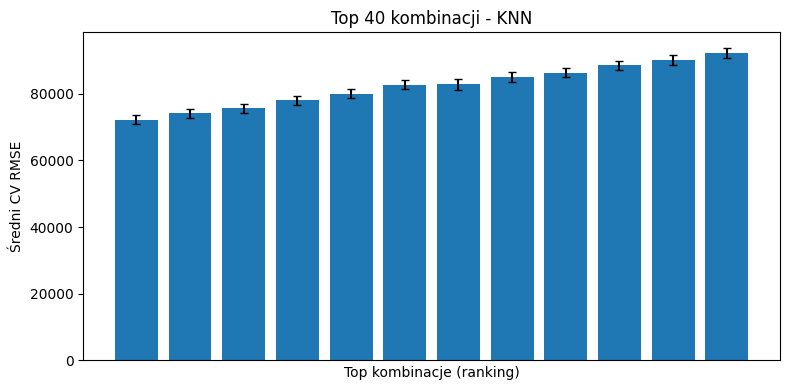


========== LINEAR ==========
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\jpiec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:318: UserWarning: The total space of parameters 1 is smaller than n_iter=50. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Najlepsze parametry:
{}
CV RMSE: 67532.892930923
RMSE TRAIN: 67483.03530768874
RMSE TEST: 68037.51577939668


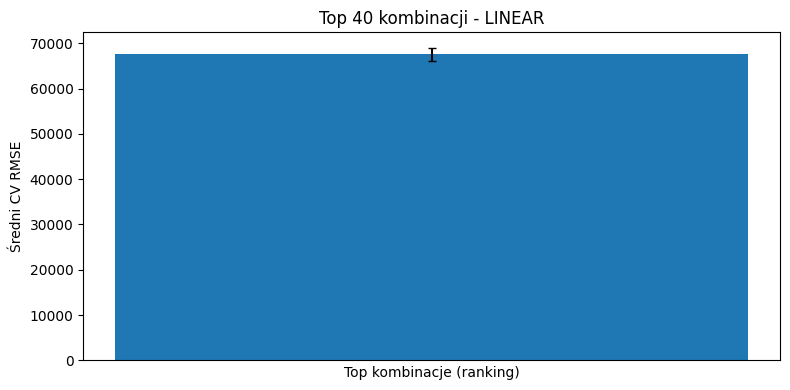


========== PODSUMOWANIE ==========


,model,cv_rmse,rmse_train,rmse_test,R2_train,R2_test,best_params
0,lgbm,53335.511453,42204.252828,52275.862209,0.877997,0.810402,"{'model__subsample': 0.8, 'model__reg_lambda':..."
1,xgb,53542.986400,38447.763864,52439.877278,0.898749,0.809210,"{'model__subsample': 0.9, 'model__reg_lambda':..."
2,rf,55213.167321,29648.434982,55027.058709,0.939791,0.789920,"{'model__n_estimators': 500, 'model__min_sampl..."
3,linear,67532.892931,67483.035308,68037.515779,0.688078,0.678835,{}
4,knn,72221.136553,69341.466037,70707.425256,0.670662,0.653134,"{'model__weights': 'uniform', 'model__p': 2, '..."


In [34]:
best_models = {}
results_list = []
top_results = {}

top_n = 40

for name, pipe in models.items():
    print(f"\n========== {name.upper()} ==========")

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dists[name],
        n_iter=50,
        scoring="neg_root_mean_squared_error",
        cv=5,
        refit=True,
        verbose=2,
        random_state=42,
        n_jobs=-1,
        error_score="raise",
        return_train_score=False
    )

    search.fit(X_train_final, y_train)

    best_model = search.best_estimator_

    y_pred_train = best_model.predict(X_train_final)
    y_pred_test = best_model.predict(X_test_final)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    best_models[name] = best_model

    results_list.append({
        "model": name,
        "cv_rmse": -search.best_score_,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "best_params": search.best_params_
    })

    print("Najlepsze parametry:")
    print(search.best_params_)
    print("CV RMSE:", -search.best_score_)
    print("RMSE TRAIN:", rmse_train)
    print("RMSE TEST:", rmse_test)

    cv_df = pd.DataFrame(search.cv_results_).copy()

    cv_df["mean_rmse"] = -cv_df["mean_test_score"]
    cv_df["std_rmse"] = cv_df["std_test_score"]

    top = cv_df.sort_values("mean_rmse", ascending=True).head(top_n).copy()
    top["rank"] = range(1, len(top) + 1)

    top_results[name] = top

    plt.figure(figsize=(8, 4))
    plt.bar(
        x=top["rank"],
        height=top["mean_rmse"],
        yerr=top["std_rmse"],
        capsize=3
    )
    plt.xlabel("Top kombinacje (ranking)")
    plt.ylabel("Średni CV RMSE")
    plt.title(f"Top {top_n} kombinacji - {name.upper()}")
    plt.xticks([])
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results_list).sort_values("rmse_test").reset_index(drop=True)

print("\n========== PODSUMOWANIE ==========")
display(results_df)

4. WYJAŚNIALNOŚĆ

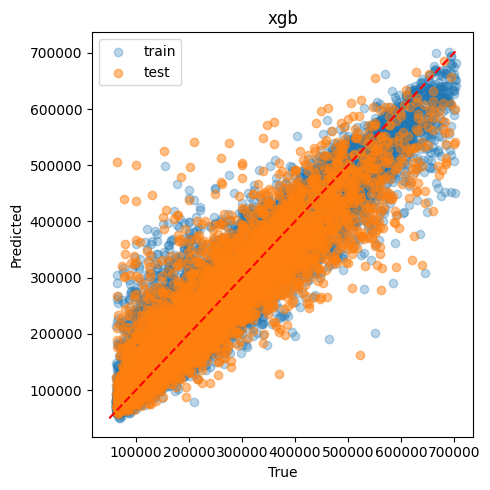

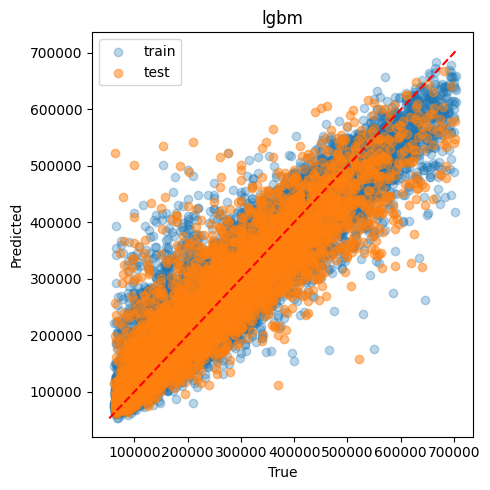

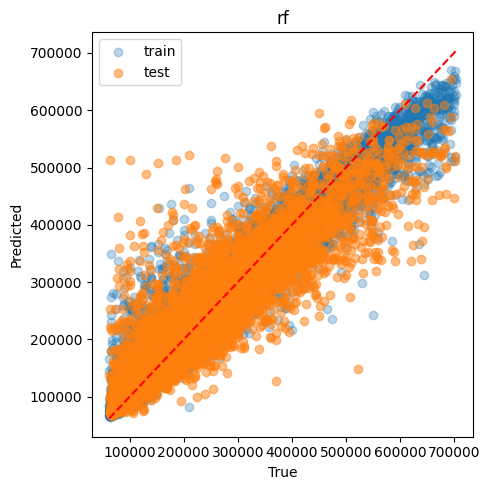

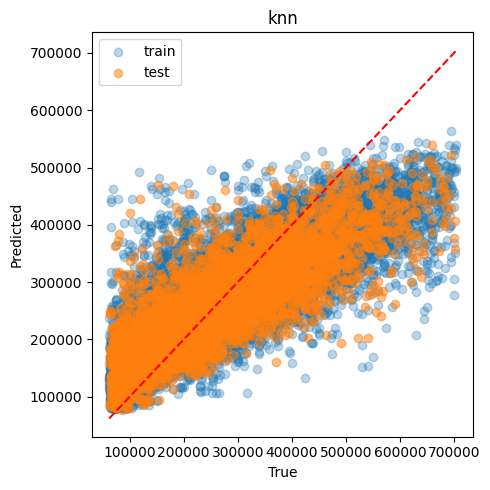

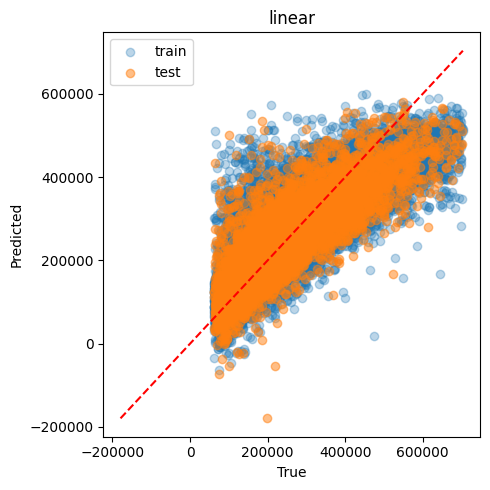

In [35]:
for name, pipe in best_models.items():
    
    y_pred_train = pipe.predict(X_train_final)
    y_pred_test = pipe.predict(X_test_final)
    
    plt.figure(figsize=(5,5))
    
    # scatter
    plt.scatter(y_train, y_pred_train, alpha=0.3, label="train")
    plt.scatter(y_test, y_pred_test, alpha=0.5, label="test")
    
    # linia 45 stopni (idealny model)
    min_val = min(y_train.min(), y_test.min(), y_pred_train.min(), y_pred_test.min())
    max_val = max(y_train.max(), y_test.max(), y_pred_train.max(), y_pred_test.max())
    
    plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
    
    plt.title(name)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

feature importances

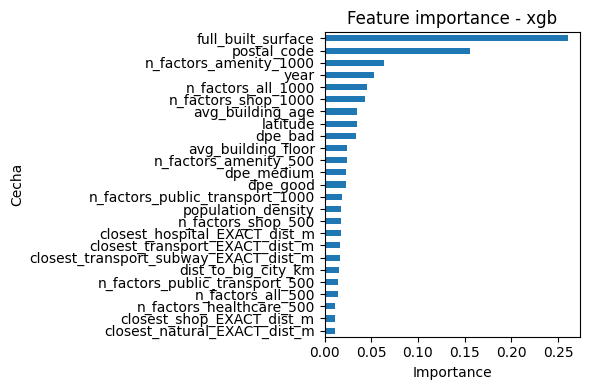

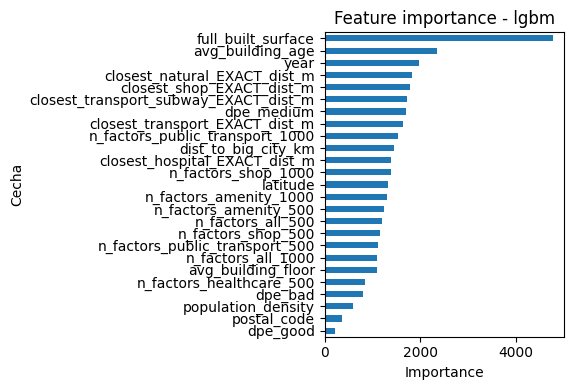

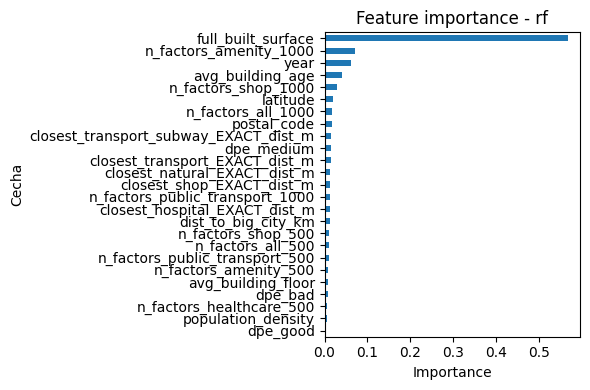

In [36]:
for name, pipe in best_models.items():
    if name in ['xgb', 'lgbm', 'rf']:
        importances = pipe.named_steps["model"].feature_importances_
        feat_imp = pd.Series(importances, index=final_features).sort_values(ascending=True)
        
        plt.figure(figsize=(6, 4))
        feat_imp.plot(kind="barh")
        
        plt.title(f"Feature importance - {name}")
        plt.xlabel("Importance")
        plt.ylabel("Cecha")
        
        plt.tight_layout()
        plt.show()

partial dependence

In [ ]:
# import numpy as np
# import pandas as pd
# import geopandas as gpd
# import folium
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors

# from shapely.geometry import Point
# from shapely.prepared import prep
# from scipy.interpolate import griddata
# from sklearn.inspection import PartialDependenceDisplay

# # =========================================================
# # USTAWIENIA
# # =========================================================
# model_name = "xgb"   # zmień na np. "lgbm", "rf" itd.
# lat_col = "latitude"
# lon_col = "longitude"

# marseille_url = "https://data.ampmetropole.fr/api/v2/catalog/datasets/contours-geographiques-des-communes-et-arrondissements-municipaux/exports/geojson"

# grid_resolution_pdp = 35     # siatka PDP z modelu
# interp_nx = 500              # gęstość interpolacji po długości
# interp_ny = 500              # gęstość interpolacji po szerokości
# pad_x = 0.03                 # poszerzenie mapy w poziomie
# pad_y = 0.03                 # poszerzenie mapy w pionie
# overlay_alpha = 0.75         # przezroczystość overlay
# zoom_start = 11

# # =========================================================
# # 1. MODEL
# # =========================================================
# model = best_models[model_name]

# # sprawdzenie kolumn
# if lat_col not in X_train_final.columns or lon_col not in X_train_final.columns:
#     raise ValueError(
#         f"Brakuje kolumn {lat_col} lub {lon_col} w X_train_final. "
#         f"Dostępne kolumny: {list(X_train_final.columns)}"
#     )

# # =========================================================
# # 2. POLICZENIE 2D PDP
# # =========================================================
# fig, ax = plt.subplots(figsize=(6, 5))

# disp = PartialDependenceDisplay.from_estimator(
#     model,
#     X_train_final,
#     features=[(lat_col, lon_col)],
#     grid_resolution=grid_resolution_pdp,
#     kind="average",
#     ax=ax
# )

# ax.set_title(f"2D PDP: {model_name}")
# plt.tight_layout()
# plt.show()

# # =========================================================
# # 3. WYCIĄGNIĘCIE SUROWYCH WYNIKÓW PDP
# # =========================================================
# pd_results = getattr(disp, "pd_results", None)
# if pd_results is None:
#     pd_results = getattr(disp, "pd_results_", None)

# if pd_results is None:
#     raise AttributeError("Nie udało się wyciągnąć pd_results z obiektu PartialDependenceDisplay.")

# pd_res = pd_results[0]

# # Dla 2D PDP:
# # grid_values[0] -> latitude
# # grid_values[1] -> longitude
# lat_vals = pd_res["grid_values"][0]
# lon_vals = pd_res["grid_values"][1]
# Z = pd_res["average"][0]   # shape: (len(lat_vals), len(lon_vals))

# LAT, LON = np.meshgrid(lat_vals, lon_vals, indexing="ij")

# # surowa siatka PDP jako DataFrame
# pdp_df = pd.DataFrame({
#     "latitude": LAT.ravel(),
#     "longitude": LON.ravel(),
#     "pdp_value": Z.ravel()
# })

# print("Podgląd siatki PDP:")
# print(pdp_df.head())

# # =========================================================
# # 4. WCZYTANIE GRANIC MARSYLII
# # =========================================================
# gdf = gpd.read_file(marseille_url).to_crs(4326)

# obj_cols = gdf.select_dtypes(include="object").columns
# mask = pd.Series(False, index=gdf.index)

# for col in obj_cols:
#     mask = mask | gdf[col].astype(str).str.contains("marseille", case=False, na=False)

# marseille = gdf[mask].copy()

# if marseille.empty:
#     print("Nie udało się automatycznie znaleźć Marsylii.")
#     print("Kolumny w pliku:", list(gdf.columns))
#     print(gdf.head())
#     raise ValueError("Trzeba ręcznie wskazać rekordy Marsylii w geojsonie.")

# # union wszystkich geometrii Marsylii
# marseille_union = marseille.geometry.union_all() if hasattr(marseille.geometry, "union_all") else marseille.geometry.unary_union
# marseille_prepared = prep(marseille_union)

# # =========================================================
# # 5. BOUNDING BOX + POSZERZENIE OBSZARU
# # =========================================================
# minx, miny, maxx, maxy = marseille.total_bounds

# minx_pad = minx - pad_x
# maxx_pad = maxx + pad_x
# miny_pad = miny - pad_y
# maxy_pad = maxy + pad_y

# # =========================================================
# # 6. INTERPOLACJA DO GŁADKIEJ SIATKI
# # =========================================================
# x = pdp_df["longitude"].values
# y = pdp_df["latitude"].values
# z = pdp_df["pdp_value"].values

# xi = np.linspace(minx_pad, maxx_pad, interp_nx)
# yi = np.linspace(miny_pad, maxy_pad, interp_ny)
# XI, YI = np.meshgrid(xi, yi)

# # najpierw cubic
# ZI = griddata((x, y), z, (XI, YI), method="cubic")

# # tam gdzie cubic nie da rady, uzupełniamy nearest
# ZI_nearest = griddata((x, y), z, (XI, YI), method="nearest")
# ZI = np.where(np.isnan(ZI), ZI_nearest, ZI)

# # =========================================================
# # 7. MASKA DO MARSYLII
# # =========================================================
# mask_inside = np.zeros(XI.shape, dtype=bool)

# for i in range(XI.shape[0]):
#     for j in range(XI.shape[1]):
#         mask_inside[i, j] = marseille_prepared.contains(Point(XI[i, j], YI[i, j]))

# ZI_masked = np.where(mask_inside, ZI, np.nan)

# # =========================================================
# # 8. PODGLĄD STATYCZNY
# # =========================================================
# fig, ax = plt.subplots(figsize=(10, 10))

# cont = ax.contourf(
#     XI, YI, ZI_masked,
#     levels=30,
#     cmap="YlOrRd"
# )

# marseille.boundary.plot(ax=ax, color="black", linewidth=1.5)

# cbar = plt.colorbar(cont, ax=ax)
# cbar.set_label("Partial dependence value")

# ax.set_xlim(minx_pad, maxx_pad)
# ax.set_ylim(miny_pad, maxy_pad)
# ax.set_title(f"Smooth 2D PDP clipped to Marseille - {model_name}")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# plt.tight_layout()
# plt.show()

# # =========================================================
# # 9. ZAPIS OVERLAY DO PNG
# # =========================================================
# vmin = np.nanquantile(ZI_masked, 0.05)
# vmax = np.nanquantile(ZI_masked, 0.95)

# norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
# cmap = plt.cm.YlOrRd

# rgba = cmap(norm(ZI_masked))

# # alfa = 0 poza Marsylią, overlay_alpha wewnątrz
# rgba[..., 3] = np.where(np.isnan(ZI_masked), 0.0, overlay_alpha)

# overlay_path = f"marseille_pdp_overlay_{model_name}.png"
# plt.imsave(overlay_path, rgba)

# print(f"Zapisano overlay: {overlay_path}")

# # =========================================================
# # 10. MAPA FOLIUM
# # =========================================================
# center_lat = (miny + maxy) / 2
# center_lon = (minx + maxx) / 2

# m = folium.Map(
#     location=[center_lat, center_lon],
#     zoom_start=zoom_start,
#     tiles="CartoDB positron"
# )

# # overlay
# folium.raster_layers.ImageOverlay(
#     name=f"PDP surface - {model_name}",
#     image=overlay_path,
#     bounds=[[miny_pad, minx_pad], [maxy_pad, maxx_pad]],
#     opacity=1.0,
#     interactive=True,
#     cross_origin=False,
#     zindex=1
# ).add_to(m)

# # granice Marsylii
# folium.GeoJson(
#     marseille,
#     name="Marseille boundary",
#     style_function=lambda x: {
#         "fillColor": "none",
#         "color": "black",
#         "weight": 2
#     }
# ).add_to(m)

# # dopasowanie widoku
# m.fit_bounds([[miny_pad, minx_pad], [maxy_pad, maxx_pad]])

# folium.LayerControl().add_to(m)

# # zapis html
# html_path = f"marseille_pdp_map_{model_name}.html"
# m.save(html_path)

# print(f"Zapisano mapę HTML: {html_path}")


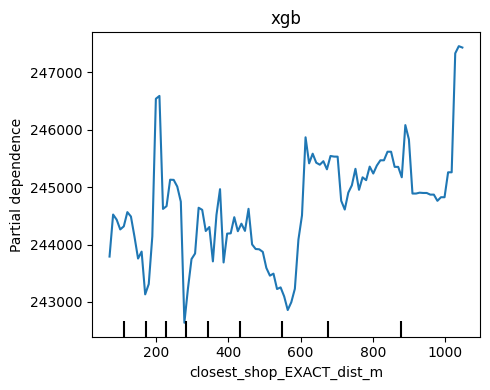

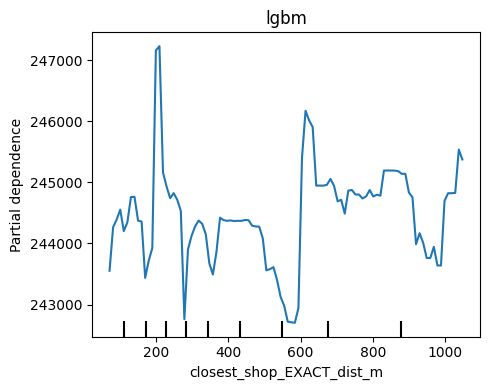

KeyboardInterrupt: 

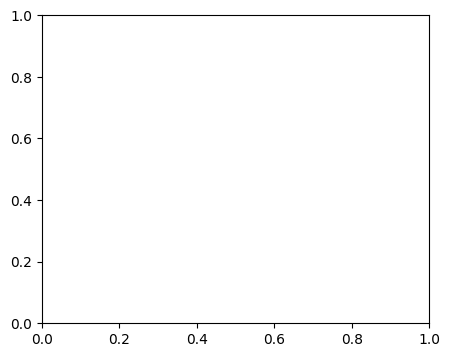

In [38]:
feature = "closest_shop_EXACT_dist_m"

for name, model in best_models.items():
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    PartialDependenceDisplay.from_estimator(model, X_train_final, features=[feature], ax=ax)
    
    ax.set_title(f"{name}")
    plt.tight_layout()
    plt.show()


wykresy shapley'a


====== xgb ======
Średnia |SHAP|: 7139.844
Max |SHAP|: 280622.25
Std predykcji: 107452.33


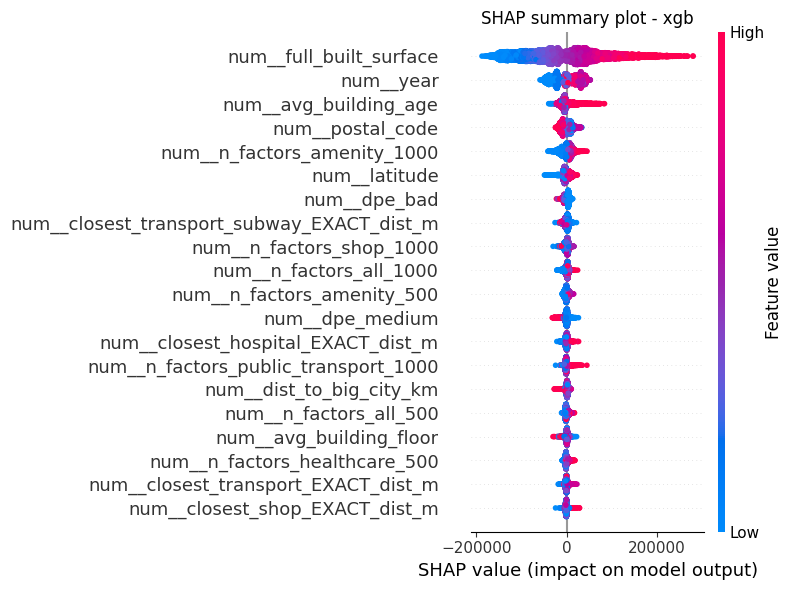

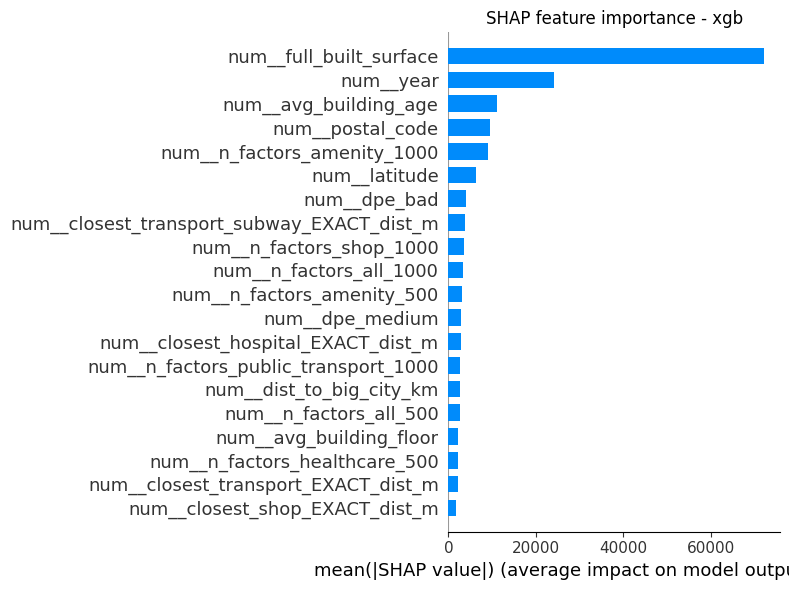


====== lgbm ======
Średnia |SHAP|: 7131.964232300058
Max |SHAP|: 285320.0942375705
Std predykcji: 107173.10889448998


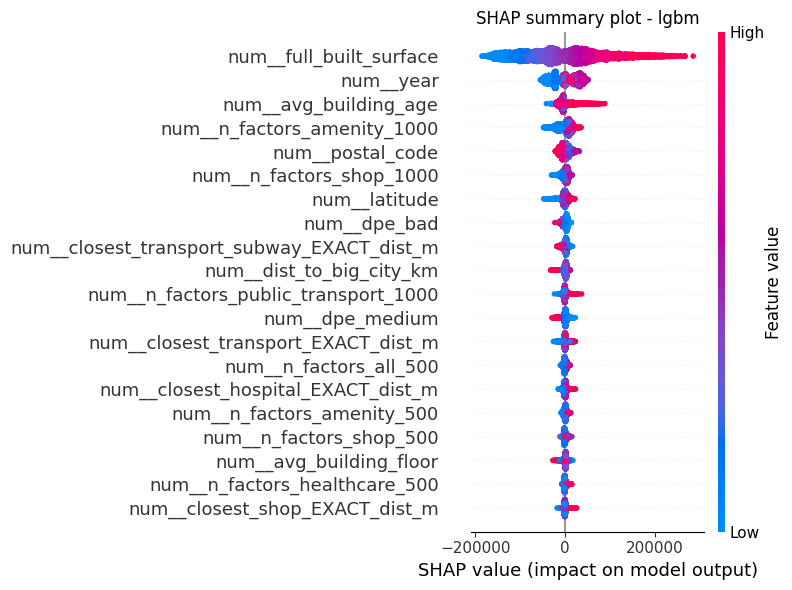

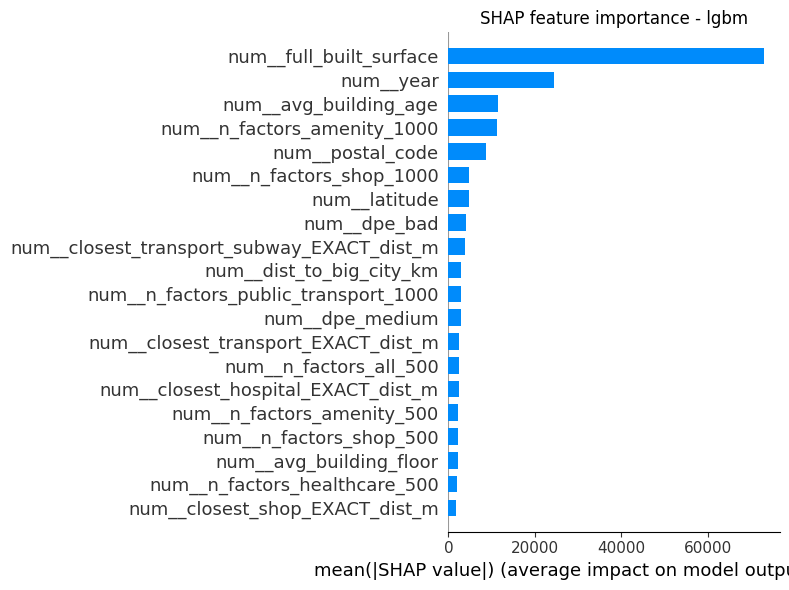


====== rf ======
Pomijam model rf - brak obsługi

====== knn ======


  0%|          | 0/50 [00:00<?, ?it/s]

Średnia |SHAP|: 5127.343899460926
Max |SHAP|: 112551.64191174669
Std predykcji: 76896.80397863965


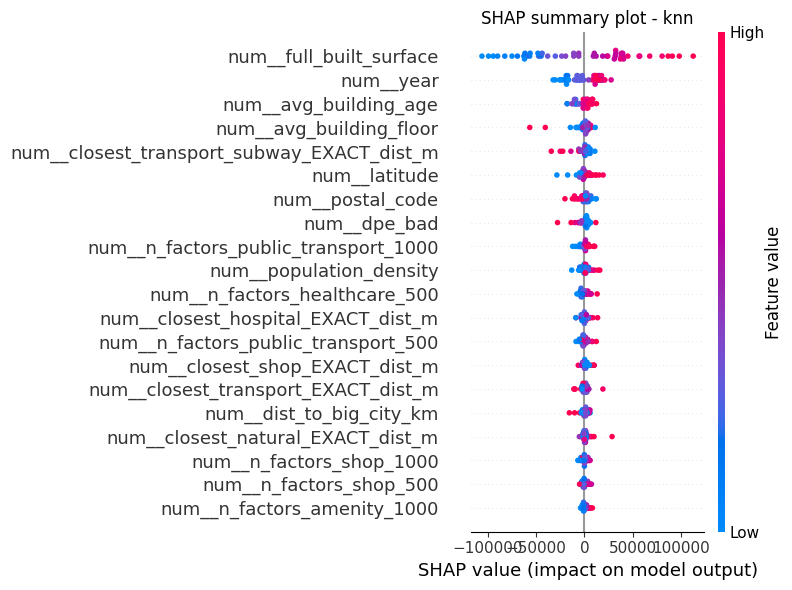

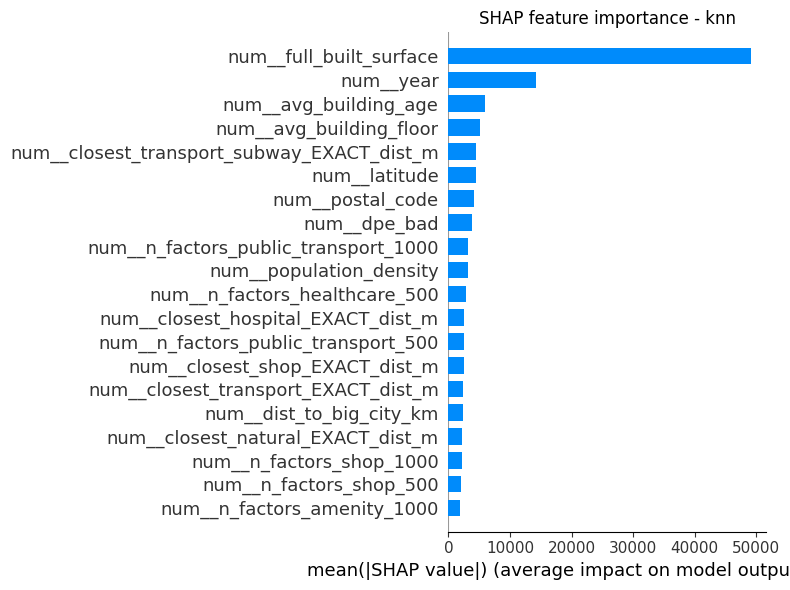


====== linear ======
Średnia |SHAP|: 16059.973921018913
Max |SHAP|: 293905.1143069399
Std predykcji: 99390.45113723676


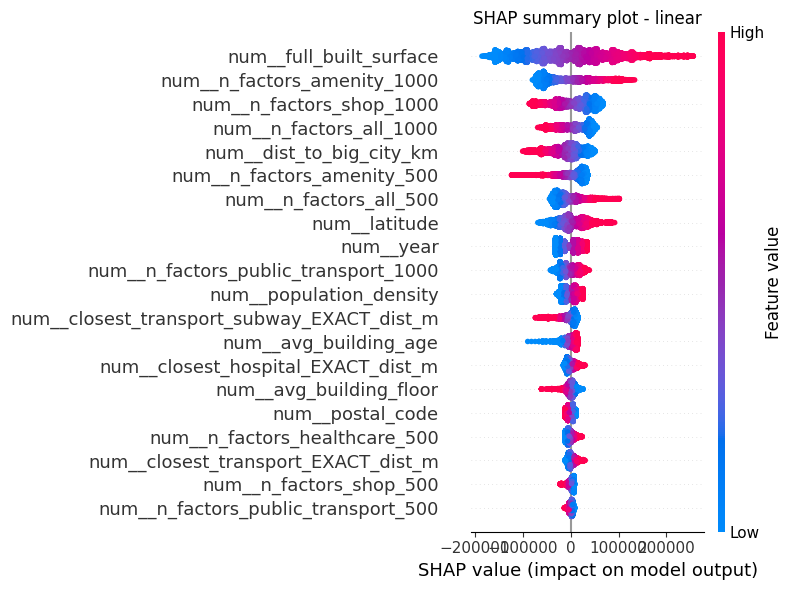

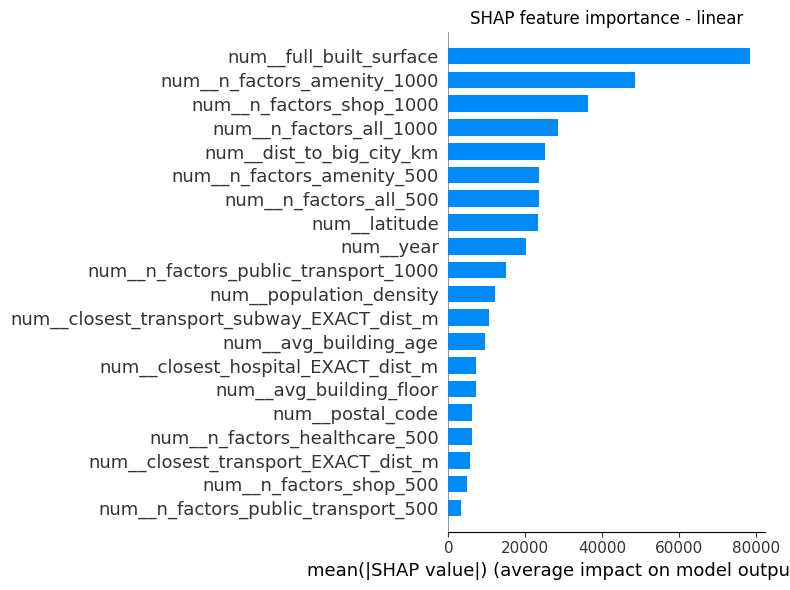

In [39]:
import shap

tree_models = ["xgb", "lgbm"]
linear_models = ["linear"]
knn_models = ["knn"]

for name, pipe in best_models.items():
    
    print(f"\n====== {name} ======")
    
    preprocessor = pipe.named_steps["preprocessor"]
    model = pipe.named_steps["model"]
    
    # transformacja danych
    X_train_trans = preprocessor.transform(X_train_final)
    X_test_trans = preprocessor.transform(X_test_final)
    feature_names = preprocessor.get_feature_names_out()
    
    if hasattr(X_train_trans, "toarray"):
        X_train_trans = X_train_trans.toarray()
    if hasattr(X_test_trans, "toarray"):
        X_test_trans = X_test_trans.toarray()
    
    # wybór explainera
    if name in tree_models:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_trans)
        X_plot = X_test_trans
    
    elif name in linear_models:
        explainer = shap.LinearExplainer(model, X_train_trans)
        shap_values = explainer.shap_values(X_test_trans)
        X_plot = X_test_trans
    
    elif name in knn_models:
        # dla KNN liczymy na próbce, bo jest wolno
        background = shap.sample(X_train_trans, 100, random_state=42)
        X_plot = X_test_trans[:50]
        
        explainer = shap.KernelExplainer(model.predict, background)
        shap_values = explainer.shap_values(X_plot)
    
    else:
        print(f"Pomijam model {name} - brak obsługi")
        continue
    
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    
    shap_values = np.array(shap_values)
    
    # statystyki
    print("Średnia |SHAP|:", np.abs(shap_values).mean())
    print("Max |SHAP|:", np.abs(shap_values).max())
    print("Std predykcji:", np.std(pipe.predict(X_test_final)))
    
    # summary dot
    shap.summary_plot(shap_values, X_plot, feature_names=feature_names, plot_type="dot", max_display=20, plot_size=(8, 6), show=False)
    plt.title(f"SHAP summary plot - {name}", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # summary bar
    shap.summary_plot(shap_values, X_plot, feature_names=feature_names, plot_type="bar", max_display=20, plot_size=(8, 6), show=False)
    plt.title(f"SHAP feature importance - {name}", fontsize=12)
    plt.tight_layout()
    plt.show()

permutation importance

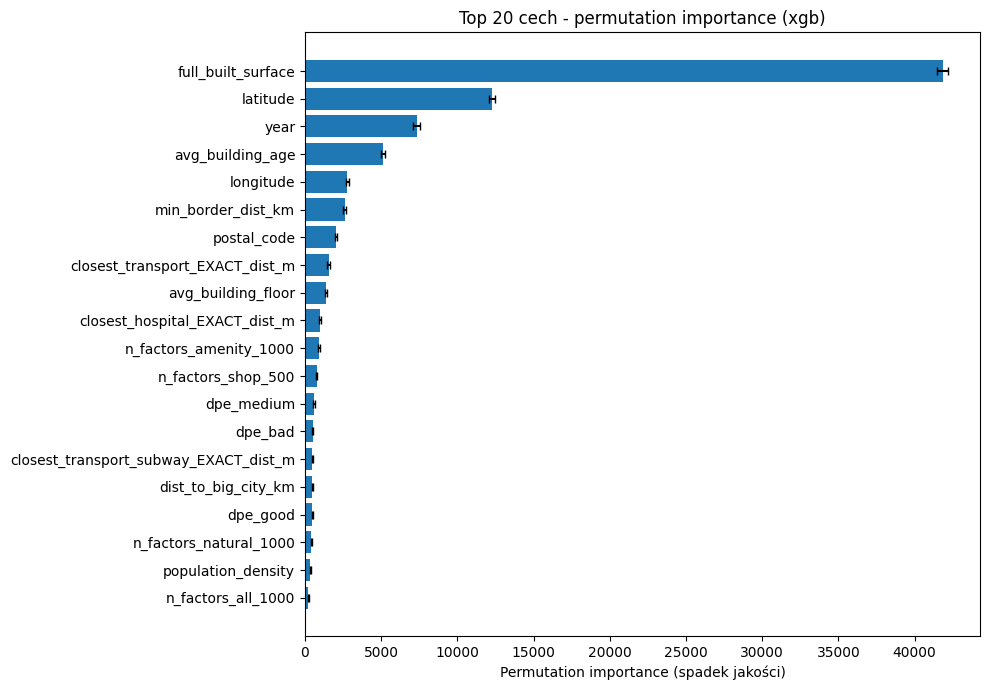

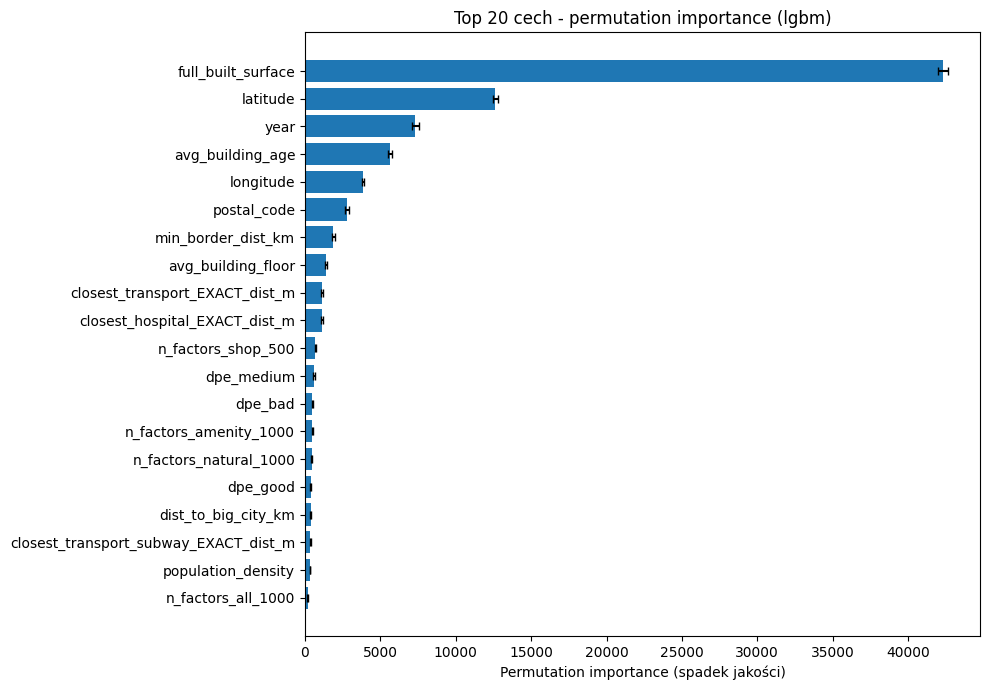

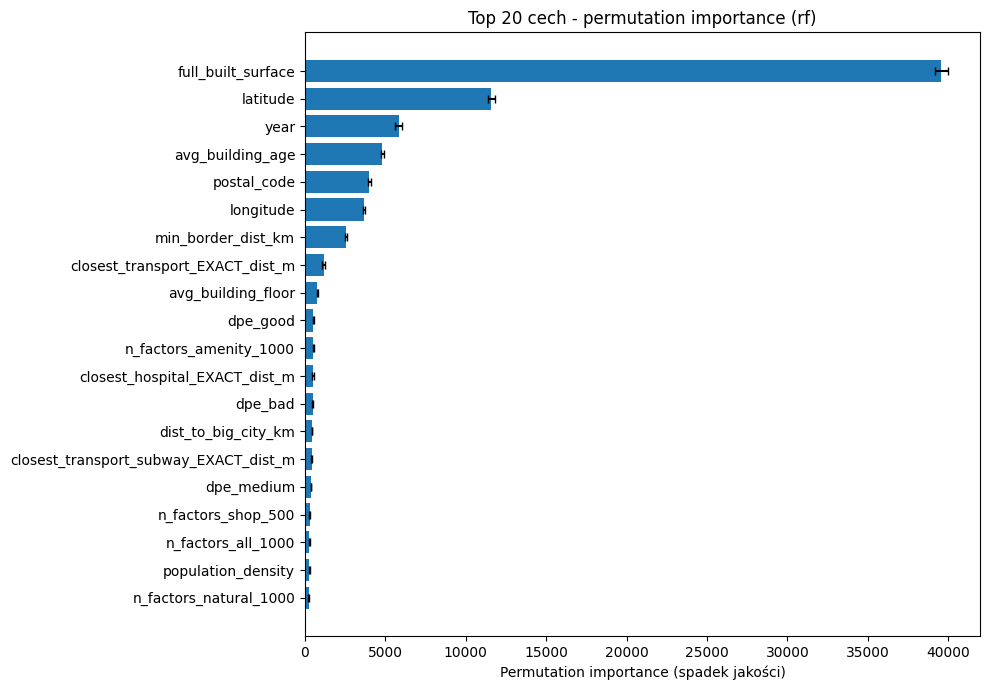

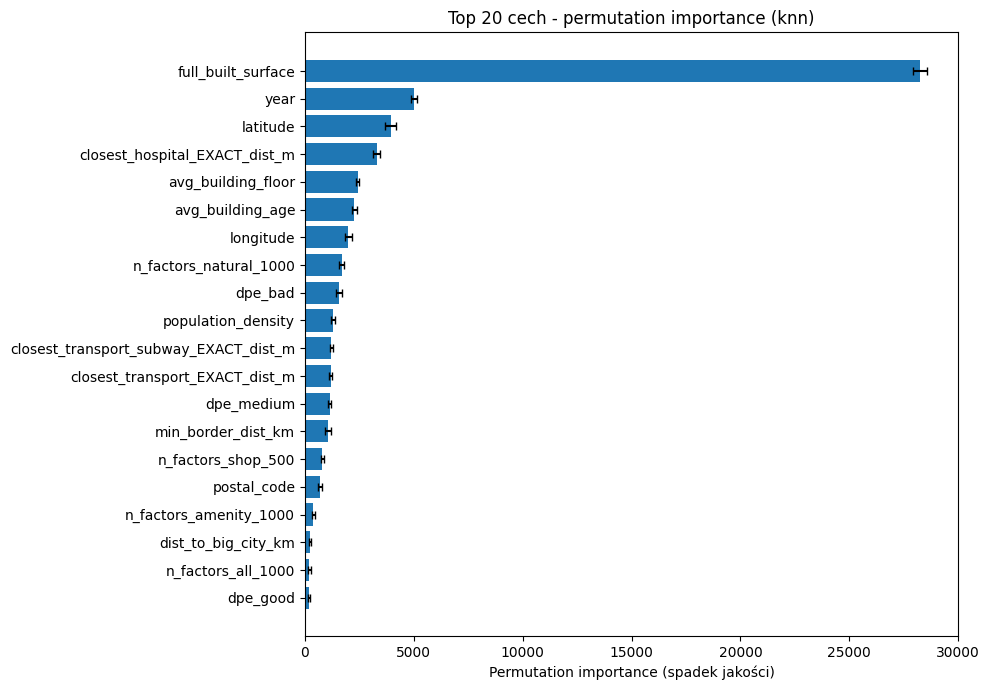

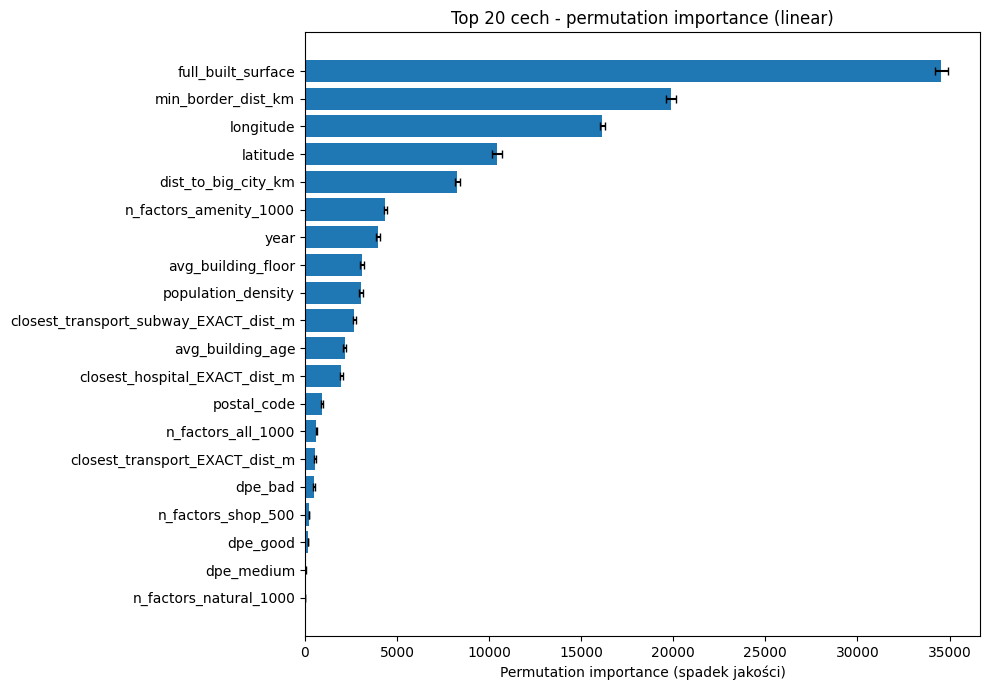

In [ ]:
from sklearn.inspection import permutation_importance

for name, model in best_models.items():
    
    perm = permutation_importance(model, X_test_final, y_test, n_repeats=10, random_state=42, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    imp_df = pd.DataFrame({
        "feature": X_test_final.columns,
        "importance": perm.importances_mean,
        "std": perm.importances_std
    }).sort_values("importance", ascending=False)
    
    # TOP 20
    top = imp_df.head(20).sort_values("importance")
    
    # WYKRES
    plt.figure(figsize=(10, 7))
    plt.barh(top["feature"], top["importance"], xerr=top["std"], capsize=3)
    plt.xlabel("Permutation importance (spadek jakości)")
    plt.title(f"Top 20 cech - permutation importance ({name})")
    plt.tight_layout()
    plt.show()

KONIEC

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import shap
from branca.colormap import linear


lyon_url = "https://preprod.data.grandlyon.com/geoserver/metropole-de-lyon/ows?SERVICE=WFS&VERSION=2.0.0&request=GetFeature&typename=metropole-de-lyon:adr_voie_lieu.adrarrond&outputFormat=application/json&SRSNAME=EPSG:4171&sortBy=gid"



best_pipe = search.best_estimator_

preprocessor = best_pipe.named_steps["preprocessor"]
model = best_pipe.named_steps["model"]


X_test_trans = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

X_test_trans_df = pd.DataFrame(
    X_test_trans,
    columns=feature_names,
    index=X_test.index
)


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans_df)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)


feat_candidates = [f for f in feature_names if "avg_building_age" in f]
print("Znalezione cechy:", feat_candidates)

if len(feat_candidates) == 0:
    raise ValueError("Nie znaleziono cechy zawierającej 'avg_building_age'.")

feat = feat_candidates[0]
feat_idx = list(feature_names).index(feat)


marseille_mask = (
    (X_test["latitude"] > 43.2) &
    (X_test["latitude"] < 43.4) &
    (X_test["longitude"] > 5.2) &
    (X_test["longitude"] < 5.5)
)

df_map = X_test.loc[
    marseille_mask,
    ["latitude", "longitude", "avg_building_age"]
].copy()

df_map["shap_value"] = shap_values[marseille_mask, feat_idx]
df_map["abs_shap"] = np.abs(df_map["shap_value"])

df_map = df_map.dropna(subset=["latitude", "longitude", "avg_building_age", "shap_value"])

if df_map.empty:
    raise ValueError("Po filtrowaniu nie ma punktów do narysowania.")


marseille_shape = gpd.read_file(lyon_url).to_crs("EPSG:4326")
marseille_shape = marseille_shape[["geometry"]].copy()


center = [df_map["latitude"].mean(), df_map["longitude"].mean()]
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

folium.GeoJson(
    data=marseille_shape.to_json(),
    name="Kontury",
    style_function=lambda x: {
        "color": "black",
        "weight": 1,
        "fillOpacity": 0
    }
).add_to(m)

# =========================
# 8. Skala kolorów SHAP
# =========================
lim = float(df_map["abs_shap"].quantile(0.95))
if lim == 0:
    lim = 1.0

cmap = linear.RdBu_11.scale(-lim, lim)
cmap.caption = "SHAP dla avg_building_age"

# =========================
# 9. Punkty
# =========================
for _, row in df_map.iterrows():
    shap_val = max(min(row["shap_value"], lim), -lim)
    radius = 3 + 7 * (min(row["abs_shap"], lim) / lim)

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color=cmap(shap_val),
        fill=True,
        fill_color=cmap(shap_val),
        fill_opacity=0.75,
        weight=0,
        popup=(
            f"avg_building_age: {row['avg_building_age']:.1f}<br>"
            f"SHAP: {row['shap_value']:.2f}<br>"
            f"|SHAP|: {row['abs_shap']:.2f}"
        )
    ).add_to(m)

# =========================
# 10. Legenda i zapis
# =========================
cmap.add_to(m)
folium.LayerControl(collapsed=True).add_to(m)

m.save("marseille_shap_avg_building_age.html")
print("Zapisano: marseille_shap_avg_building_age.html")

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import shap
from branca.colormap import linear

feature_base = "closest_hospital_EXACT_dist_m"

marseille_url = "https://data.ampmetropole.fr/api/v2/catalog/datasets/contours-geographiques-des-communes-et-arrondissements-municipaux/exports/geojson"

best_pipe = search.best_estimator_

preprocessor = best_pipe.named_steps["preprocessor"]
model = best_pipe.named_steps["model"]

X_test_trans = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

X_test_trans_df = pd.DataFrame(
    X_test_trans,
    columns=feature_names,
    index=X_test_15.index
)

# =========================
# 4. SHAP values
# =========================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans_df)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

# =========================
# 5. Znalezienie kolumny po preprocessingu
# =========================
feat_candidates = [f for f in feature_names if feature_base in f]
print("Znalezione cechy:", feat_candidates)

feat = feat_candidates[0]
feat_idx = list(feature_names).index(feat)

# =========================
# 6. Filtr punktów do Marsylii
# =========================
marseille_mask = (
    (X_test["latitude"] > 43.2) &
    (X_test["latitude"] < 43.4) &
    (X_test["longitude"] > 5.2) &
    (X_test["longitude"] < 5.5)
)

df_map = X_test.loc[
    marseille_mask,
    ["latitude", "longitude", feature_base]
].copy()

df_map["shap_value"] = shap_values[marseille_mask.to_numpy(), feat_idx]
df_map["abs_shap"] = np.abs(df_map["shap_value"])

df_map = df_map.dropna(subset=["latitude", "longitude", feature_base, "shap_value"])

# =========================
# 7. Wczytanie konturów
# =========================
marseille_shape = gpd.read_file(marseille_url).to_crs("EPSG:4326")
marseille_shape = marseille_shape[["geometry"]].copy()

# =========================
# 8. Mapa
# =========================
center = [df_map["latitude"].mean(), df_map["longitude"].mean()]
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

folium.GeoJson(
    data=marseille_shape.to_json(),
    name="Kontury",
    style_function=lambda x: {
        "color": "black",
        "weight": 1,
        "fillOpacity": 0
    }
).add_to(m)

# =========================
# 9. Skala kolorów SHAP
# =========================
lim = float(df_map["abs_shap"].quantile(0.95))
if lim == 0:
    lim = 1.0

cmap = linear.RdBu_11.scale(-lim, lim)
cmap.caption = f"SHAP dla {feature_base}"

# =========================
# 10. Punkty
# =========================
for _, row in df_map.iterrows():
    shap_val = max(min(row["shap_value"], lim), -lim)
    radius = 3 + 7 * (min(row["abs_shap"], lim) / lim)

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color=cmap(shap_val),
        fill=True,
        fill_color=cmap(shap_val),
        fill_opacity=0.75,
        weight=0,
        popup=(
            f"{feature_base}: {row[feature_base]:.0f} m<br>"
            f"SHAP: {row['shap_value']:.2f}<br>"
            f"|SHAP|: {row['abs_shap']:.2f}"
        )
    ).add_to(m)

# =========================
# 11. Legenda i zapis
# =========================
cmap.add_to(m)
folium.LayerControl(collapsed=True).add_to(m)

output_name = f"marseille_shap_{feature_base}.html"
m.save(output_name)
print(f"Zapisano: {output_name}")

In [ ]:
# predykcje
y_pred = best_pipe.predict(X_test)

# dataframe do mapy
df_map = X_test.copy()
df_map["y_true"] = y_test.values
df_map["y_pred"] = y_pred
df_map["error"] = df_map["y_true"] - df_map["y_pred"]
df_map["abs_error"] = np.abs(df_map["error"])
df_map["pct_error"] = 100 * df_map["error"] / df_map["y_true"]

# centrum mapy
center = [df_map["latitude"].mean(), df_map["longitude"].mean()]
m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# przedziały błędu
bins = [-np.inf, -1000, -500, 500, 1000, np.inf]
labels = [
    "duże przeszacowanie",
    "lekkie przeszacowanie",
    "trafione",
    "lekkie niedoszacowanie",
    "duże niedoszacowanie"
]

df_map["error_class"] = pd.cut(df_map["error"], bins=bins, labels=labels)

# kolory dla klas
color_map = {
    "duże przeszacowanie": "darkblue",
    "lekkie przeszacowanie": "lightblue",
    "trafione": "gray",
    "lekkie niedoszacowanie": "orange",
    "duże niedoszacowanie": "red"
}

# rysowanie punktów
for _, row in df_map.iterrows():
    cls = str(row["error_class"])
    col = color_map.get(cls, "black")

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,
        color=col,
        fill=True,
        fill_color=col,
        fill_opacity=0.8,
        weight=0,
        popup=(
            f"true: {row['y_true']:.0f}<br>"
            f"pred: {row['y_pred']:.0f}<br>"
            f"error: {row['error']:.0f}<br>"
            f"pct_error: {row['pct_error']:.1f}%<br>"
            f"class: {cls}"
        )
    ).add_to(m)

m.save("errors.html")

=============

In [ ]:
selector = pipe.named_steps["features_selector"]
cols = pipe.named_steps["preprocessor"].get_feature_names_out()

# najpierw uwzględnij VarianceThreshold
var_mask = pipe.named_steps["variance"].get_support()
cols_after_variance = cols[var_mask]

# potem maska z SelectFromModel
sel_mask = selector.get_support()

features = pd.DataFrame({
    "selected_features": cols_after_variance[sel_mask],
    "importances": selector.estimator_.feature_importances_[sel_mask]
}).sort_values("importances", ascending=False)

features

modele

In [ ]:
knn_grid = {"n_neighbors": [3,5,7,9,11,15,21], "weights": ["uniform","distance"], "p": [1,2], "leaf_size": [20,30,40]}

rf_grid = {"n_estimators": [200,400,600], "max_depth": [None,10,20,30], "min_samples_split": [2,5,10], "min_samples_leaf": [1,2,4], "max_features": ["sqrt","log2",0.5]}

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import shap
from branca.colormap import linear

# =========================
# 1. Najlepszy pipeline
# =========================
best_pipe = search.best_estimator_

preprocessor = best_pipe.named_steps["preprocessor"]
model = best_pipe.named_steps["model"]

# =========================
# 2. Transformacja danych testowych
# =========================
X_test_trans = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

X_test_trans_df = pd.DataFrame(
    X_test_trans,
    columns=feature_names,
    index=X_test.index
)

# =========================
# 3. SHAP values
# =========================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans_df)

# =========================
# 4. Znalezienie kolumny dla full_built_surface
# =========================
feat_candidates = [f for f in feature_names if "full_built_surface" in f]

print("Znalezione cechy:", feat_candidates)

feat = feat_candidates[0]   # powinno znaleźć np. 'num__full_built_surface'

# =========================
# 5. DataFrame do mapy
# =========================
df_map = X_test[["latitude", "longitude", "full_built_surface"]].copy()
df_map["shap_value"] = shap_values[:, list(feature_names).index(feat)]
df_map["abs_shap"] = np.abs(df_map["shap_value"])

# =========================
# 6. Wczytanie konturów Lyonu
# =========================
lyon_url = "https://preprod.data.grandlyon.com/geoserver/metropole-de-lyon/ows?SERVICE=WFS&VERSION=2.0.0&request=GetFeature&typename=metropole-de-lyon:adr_voie_lieu.adrarrond&outputFormat=application/json&SRSNAME=EPSG:4171&sortBy=gid"

lyon_shape = gpd.read_file(lyon_url).to_crs("EPSG:4326")
lyon_shape = lyon_shape[["geometry"]].copy()

# =========================
# 7. Mapa
# =========================
center = [df_map["latitude"].mean(), df_map["longitude"].mean()]
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

# kontury dzielnic
folium.GeoJson(
    data=lyon_shape.to_json(),
    name="Kontury Lyonu",
    style_function=lambda x: {
        "color": "black",
        "weight": 2,
        "fillOpacity": 0
    }
).add_to(m)

# =========================
# 8. Skala kolorów SHAP
# =========================
lim = float(df_map["abs_shap"].quantile(0.95))

cmap = linear.RdBu_11.scale(-lim, lim)
cmap.caption = "SHAP dla full_built_surface"

# =========================
# 9. Punkty na mapie
# =========================
for _, row in df_map.iterrows():
    shap_val = max(min(row["shap_value"], lim), -lim)
    
    # wielkość punktu zależna od siły wpływu
    radius = 3 + 7 * (min(row["abs_shap"], lim) / lim if lim > 0 else 0)

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color=cmap(shap_val),
        fill=True,
        fill_color=cmap(shap_val),
        fill_opacity=0.75,
        weight=0,
        popup=(
            f"full_built_surface: {row['full_built_surface']:.1f}<br>"
            f"SHAP: {row['shap_value']:.2f}<br>"
            f"|SHAP|: {row['abs_shap']:.2f}"
        )
    ).add_to(m)

# =========================
# 10. Legenda i zapis
# =========================
cmap.add_to(m)
folium.LayerControl(collapsed=True).add_to(m)

m.save("lyon_shap_full_built_surface.html")

In [ ]:
shap.dependence_plot(
    "num__closest_transport_subway_EXACT_dist_m",
    shap_values,
    X_test_trans_df
)

In [ ]:
shap.dependence_plot(
    "closest_hospital_EXACT_dist_m",
    shap_values,
    X_test
)

In [ ]:
[f for f in X_test_trans_df.columns if "closest_subway_transport_EXACT_dist_m" in f]

In [ ]:
print(num_features)
print(cat_features)